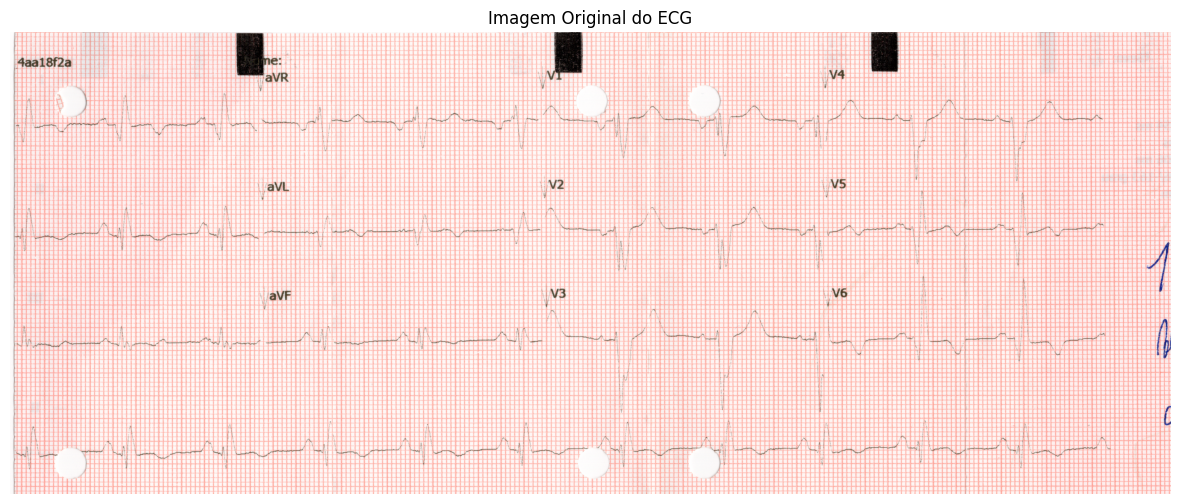

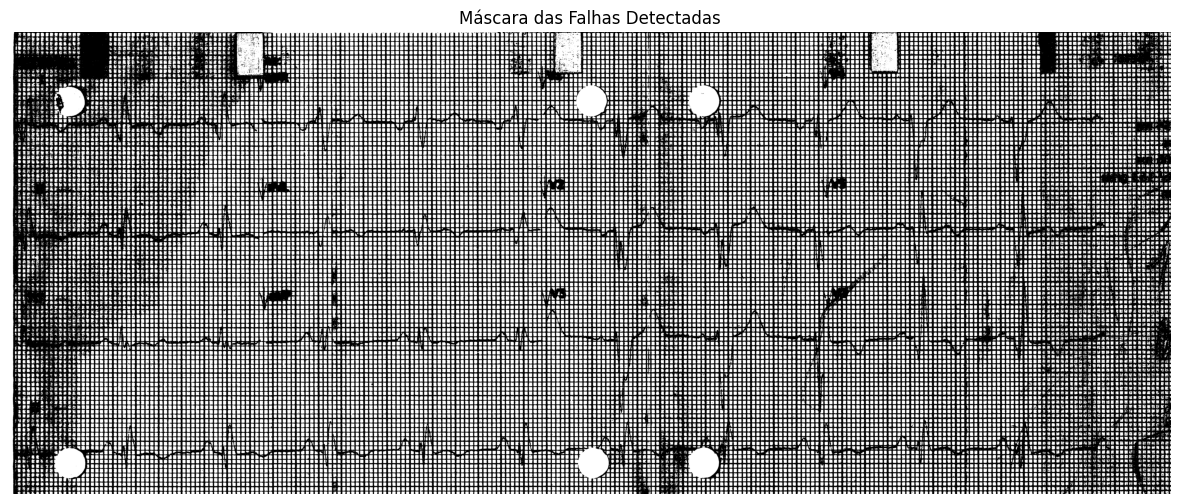

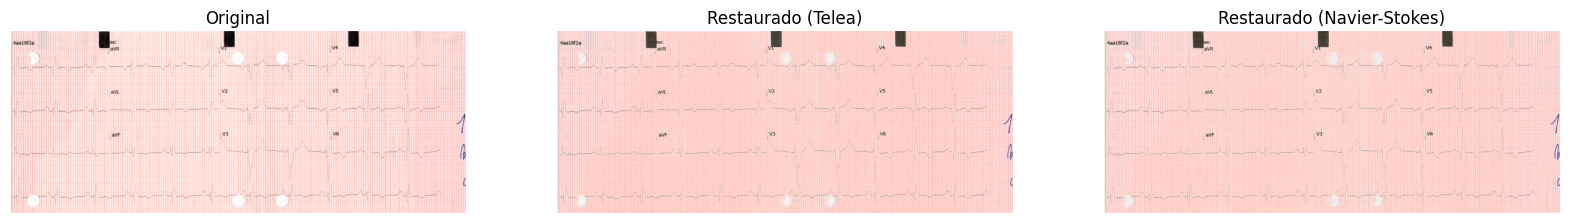

Resultados salvos como 'ecg_restaurado_telea.png' e 'ecg_restaurado_ns.png'


In [1]:
# # Teste restauração de ECG com Inpainting (OpenCV)

# %% 
import cv2
import numpy as np
import matplotlib.pyplot as plt

# carregar imagem
img = cv2.imread("bucket/img20250221_10384557.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16,6))
plt.imshow(img_rgb)
plt.title("Imagem Original do ECG")
plt.axis("off")
plt.show()

# %% 
# converter para escala de cinza
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# detectar regiões escuras (linhas pretas e furos)
_, mask_dark = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY_INV)

# detectar regiões muito claras (furos brancos)
_, mask_light = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)

# máscara final (pretos + brancos)
mask = cv2.bitwise_or(mask_dark, mask_light)

plt.figure(figsize=(16,6))
plt.imshow(mask, cmap="gray")
plt.title("Máscara das Falhas Detectadas")
plt.axis("off")
plt.show()

# %%
# aplicar inpainting (Telea e Navier-Stokes)
restored_telea = cv2.inpaint(img_rgb, mask, 3, cv2.INPAINT_TELEA)
restored_ns = cv2.inpaint(img_rgb, mask, 3, cv2.INPAINT_NS)

# visualizar resultados
fig, ax = plt.subplots(1,3, figsize=(20,8))
ax[0].imshow(img_rgb)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(restored_telea)
ax[1].set_title("Restaurado (Telea)")
ax[1].axis("off")

ax[2].imshow(restored_ns)
ax[2].set_title("Restaurado (Navier-Stokes)")
ax[2].axis("off")

plt.show()

# %% 
# salvar resultados
cv2.imwrite("ecg_restaurado_telea.png", cv2.cvtColor(restored_telea, cv2.COLOR_RGB2BGR))
cv2.imwrite("ecg_restaurado_ns.png", cv2.cvtColor(restored_ns, cv2.COLOR_RGB2BGR))

print("Resultados salvos como 'ecg_restaurado_telea.png' e 'ecg_restaurado_ns.png'")

